# Sweep / Chirp Generator

A chirp sweeps its instantaneous frequency continuously from `f_start` to `f_end` Hz over `duration` seconds. It is the standard stimulus for measuring the impulse response of any audio system via deconvolution.

| Function | Description |
| --- | --- |
| `generate_chirp` | Frequency sweep from `f_start` to `f_end`. `method="logarithmic"` (default) sweeps at a constant rate in **octaves/s** — equal time per octave, matched to human pitch perception. `method="linear"` sweeps at constant **Hz/s** — spends more time in the high-frequency region. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_chirp

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Logarithmic vs linear chirp, both sweeping 20 Hz → 20 kHz over 1 second.

**2 × 2 grid:**
- **Top-left — logarithmic chirp, time domain (first 50 ms):** dense rapid oscillation at low frequencies in the time-domain detail window; the waveform frequency rises quickly (log scale) even in the first few ms
- **Top-right — linear chirp, time domain (first 50 ms):** slower oscillation at the start because the linear sweep starts from the same 20 Hz but advances at a much slower Hz/s rate in the low-frequency region
- **Bottom-left — logarithmic chirp spectrogram:** uniform brightness across the full 20 Hz–20 kHz range; equal time spent per octave, so each octave band is equally excited
- **Bottom-right — linear chirp spectrogram:** low frequencies pass quickly (most energy concentrated in the first few hundred ms); the majority of the 1 s sweep is spent in the high-frequency region

The **logarithmic sweep is preferred for audio impulse-response measurement** because it distributes stimulus energy evenly across octaves, matching psychoacoustic weighting and preventing saturation of low-frequency resonances.


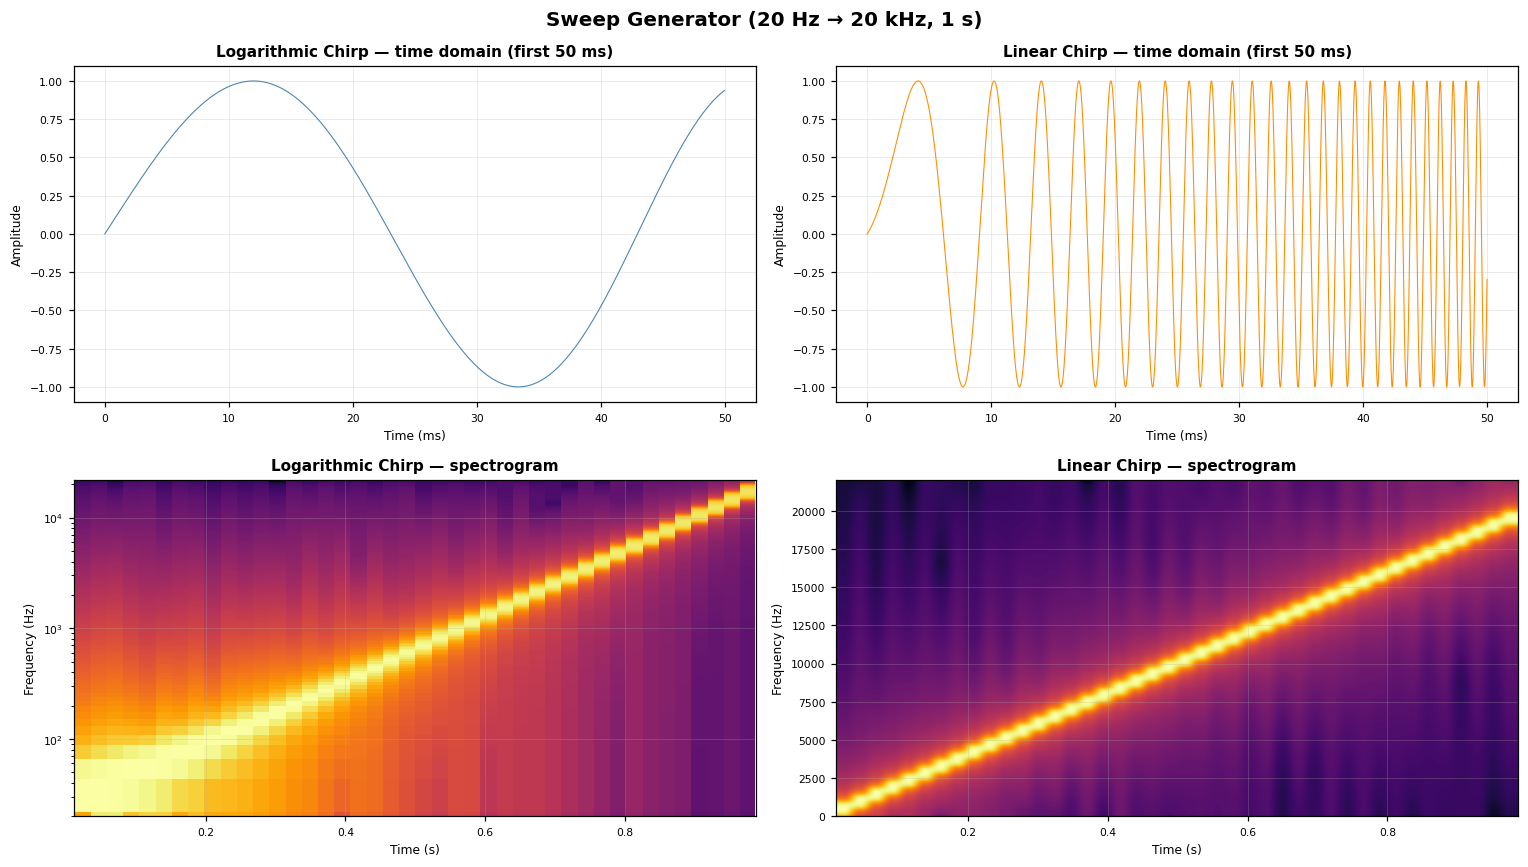

In [2]:
FS = 44100
DURATION = 1.0
F_START = 20.0
F_END = 20000.0

t_log, chirp_log = generate_chirp(f_start=F_START, f_end=F_END, fs=FS, duration=DURATION, method="logarithmic")
t_lin, chirp_lin = generate_chirp(f_start=F_START, f_end=F_END, fs=FS, duration=DURATION, method="linear")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Time domain (first 50 ms to show waveform detail)
N_SHOW = int(0.05 * FS)

axes[0, 0].plot(t_log[:N_SHOW] * 1000, chirp_log[:N_SHOW], linewidth=0.7, color="steelblue")
axes[0, 0].set_title("Logarithmic Chirp — time domain (first 50 ms)", fontsize=10, fontweight="bold")
axes[0, 0].set_xlabel("Time (ms)", fontsize=8)
axes[0, 0].set_ylabel("Amplitude", fontsize=8)

axes[0, 1].plot(t_lin[:N_SHOW] * 1000, chirp_lin[:N_SHOW], linewidth=0.7, color="darkorange")
axes[0, 1].set_title("Linear Chirp — time domain (first 50 ms)", fontsize=10, fontweight="bold")
axes[0, 1].set_xlabel("Time (ms)", fontsize=8)
axes[0, 1].set_ylabel("Amplitude", fontsize=8)

# Spectrograms
NPERSEG = 2048

axes[1, 0].specgram(
    chirp_log, Fs=FS, NFFT=NPERSEG, noverlap=NPERSEG // 2,
    cmap="inferno", scale="dB",
)
axes[1, 0].set_title("Logarithmic Chirp — spectrogram", fontsize=10, fontweight="bold")
axes[1, 0].set_xlabel("Time (s)", fontsize=8)
axes[1, 0].set_ylabel("Frequency (Hz)", fontsize=8)
axes[1, 0].set_yscale("log")
axes[1, 0].set_ylim(F_START, FS / 2)

axes[1, 1].specgram(
    chirp_lin, Fs=FS, NFFT=NPERSEG, noverlap=NPERSEG // 2,
    cmap="inferno", scale="dB",
)
axes[1, 1].set_title("Linear Chirp — spectrogram", fontsize=10, fontweight="bold")
axes[1, 1].set_xlabel("Time (s)", fontsize=8)
axes[1, 1].set_ylabel("Frequency (Hz)", fontsize=8)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.4)

fig.suptitle("Sweep Generator (20 Hz → 20 kHz, 1 s)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()